In [1]:
import sys
import os

sys.path.append(os.path.abspath("..")) 
import models

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from models.kuramoto_graph import KuramotoGraph

In [2]:
# Suppose G is your KuramotoGraph instance
G = KuramotoGraph(200)

G.positions()
G.distances()
A = G.graphon(k=2, lam=0.5)  # adjacency from graphon

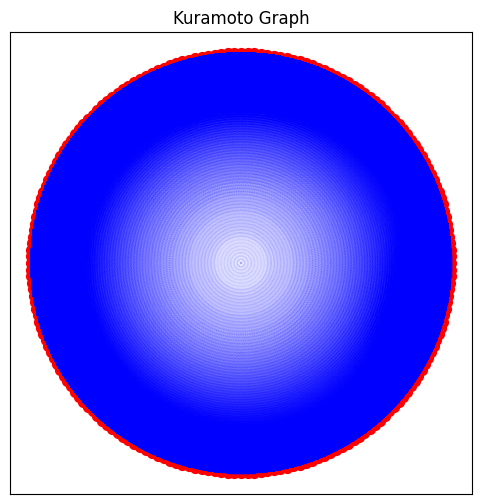

In [3]:
G.plot_graph(G.x, A)


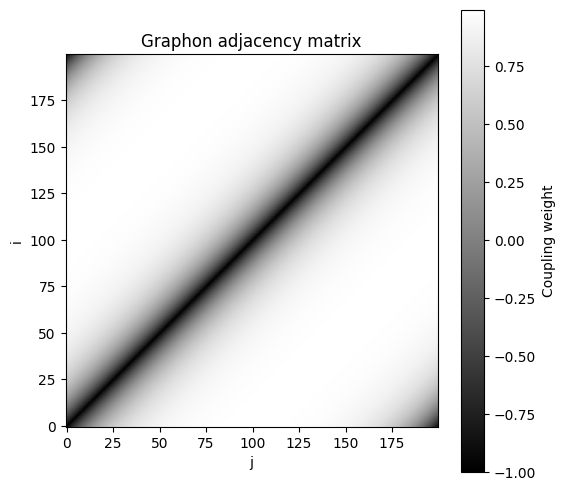

In [4]:
G.plot_graphon(A)

In [5]:
dt = 0.01
T=5

# simulate dynamics
sol = G.simulate(T=T, dt=dt)


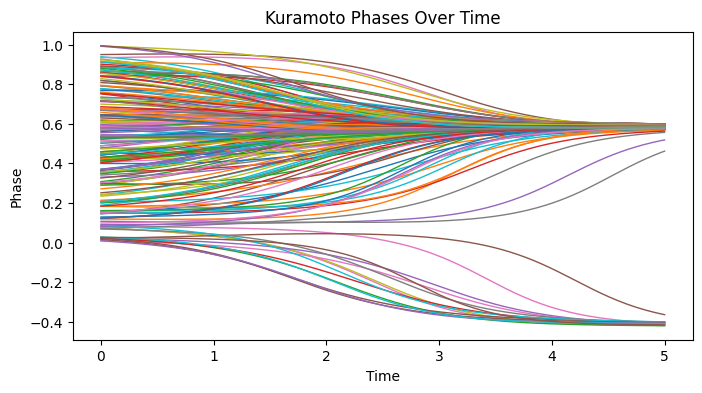

In [6]:
plt.figure(figsize=(8,4))
for i in range(sol.ys.shape[1]):
    plt.plot(sol.ts, sol.ys[:, i], lw=1)
plt.xlabel('Time')
plt.ylabel('Phase')
plt.title('Kuramoto Phases Over Time')
plt.show()


In [7]:
u_discrete = sol.ys[-1]  


In [8]:
def m_twisted_state(x, m=1):
    return (m * x / (2*jnp.pi)) % 1

N = int(T//dt)
x_cont = jnp.linspace(0, 2*jnp.pi, N, endpoint=False)
u_cont = m_twisted_state(x_cont, m=1)
print(u_cont.shape)
# ms=jnp.array([1, 2, 3, 4])
# us_cont = jax.vmap(lambda _m: m_twisted_state(x_cont, _m))(ms)
# print(us_cont.shape)


(499,)


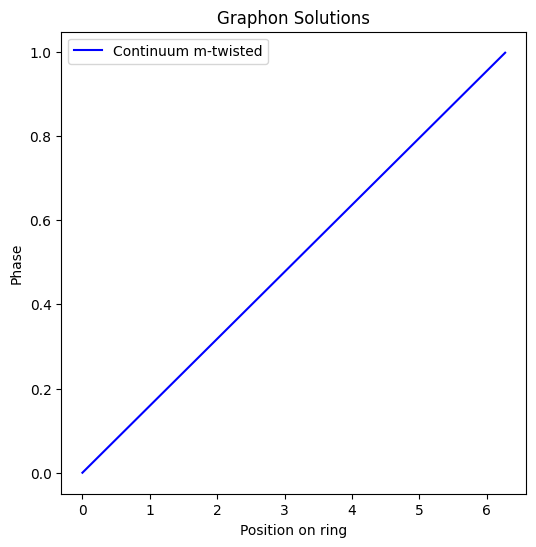

In [9]:

plt.figure(figsize=(6,6))
# for us in us_cont:
#     plt.plot(x_cont, us, 'b-', label='Continuum m-twisted')  
plt.plot(x_cont, u_cont, 'b-', label='Continuum m-twisted')  

plt.xlabel('Position on ring')
plt.ylabel('Phase')
plt.title('Graphon Solutions')
plt.legend()
plt.show()

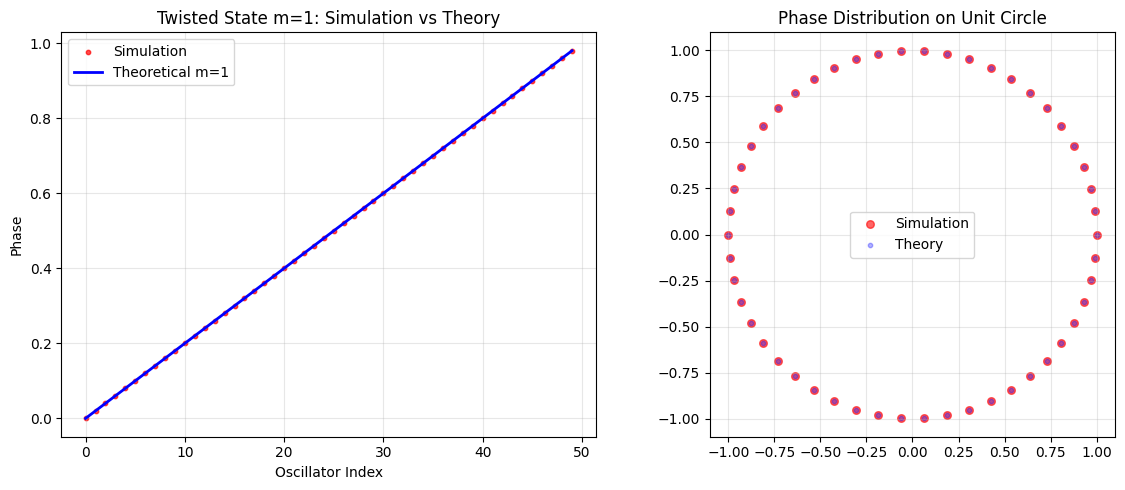

m=1: Order parameter = 0.000 (0=incoherent, 1=sync)


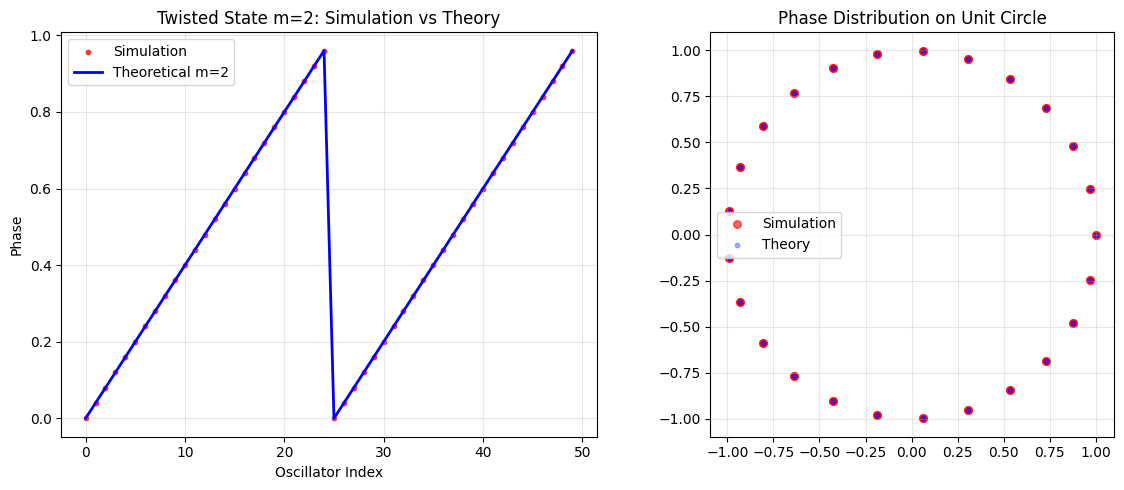

m=2: Order parameter = 0.000 (0=incoherent, 1=sync)


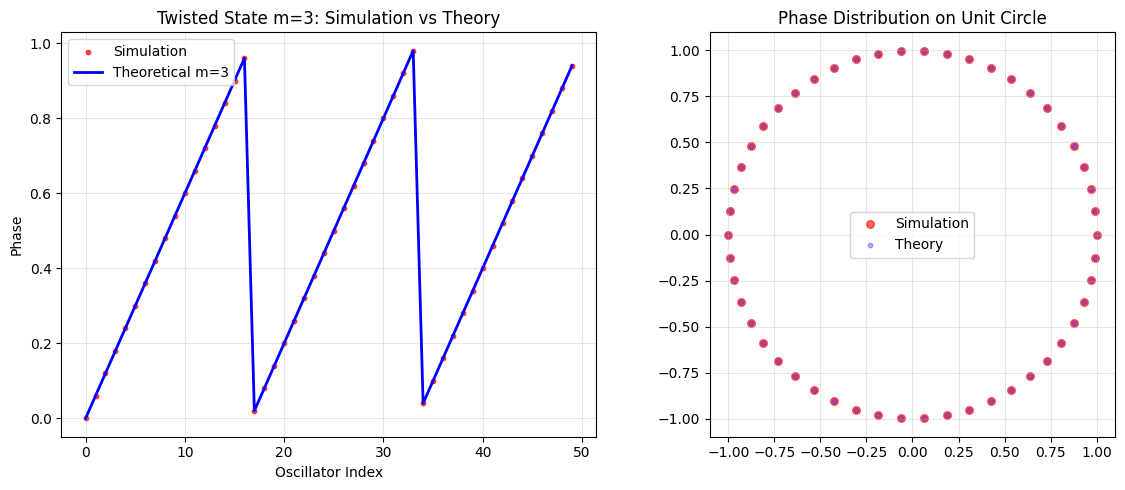

m=3: Order parameter = 0.000 (0=incoherent, 1=sync)


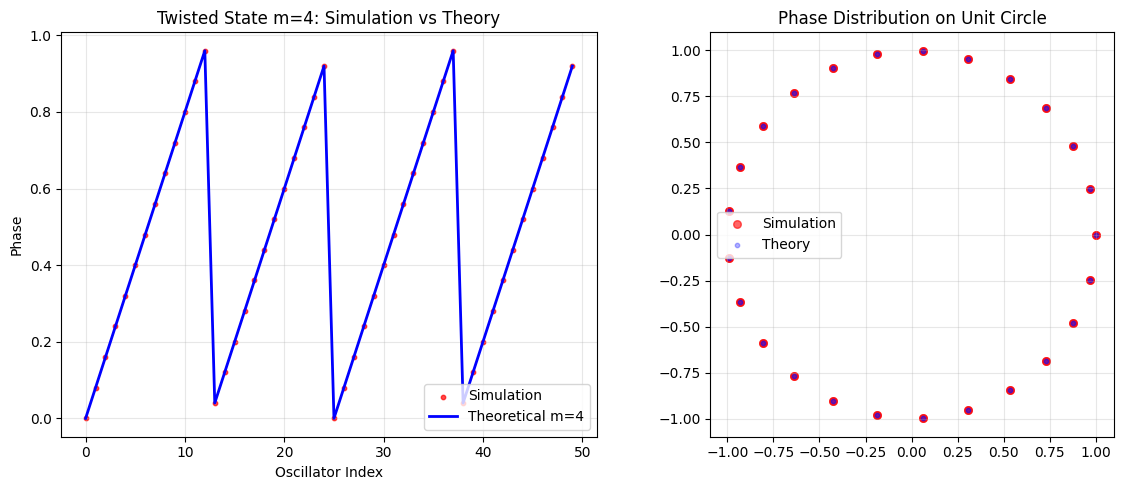

m=4: Order parameter = 0.000 (0=incoherent, 1=sync)


In [10]:
def simulate_twisted_states():
    n = 50  # Use more oscillators for clearer patterns
    
    for m in [1, 2, 3, 4]:  # Different numbers of twists
        # Create graph with twisted state initial condition
        u0_twisted = KuramotoGraph(n).m_twisted_state(m=m)
        G = KuramotoGraph(n, u0=u0_twisted)
        
        # Set up positions and graphon
        G.positions()
        G.distances()
        
        # Use weaker, longer-range coupling for twisted state stability
        A = G.graphon(k=0.5, lam=0.8)  # Weaker coupling, longer range
        G.A = A
        
        # Simulate with smaller time step
        sol = G.simulate(T=20.0, dt=0.005)
        
        # Plot results
        plot_twisted_state_comparison(G, sol, m=m)

def plot_twisted_state_comparison(G, sol, m=1):
    """Plot simulation results vs theoretical twisted state"""
    final_phases = sol.ys[-1]  # Final state
    theoretical_phases = G.m_twisted_state(m=m)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Phase profile (like in the Springer figure)
    oscillator_index = jnp.arange(G.n)
    ax1.scatter(oscillator_index, final_phases, color='red', s=10, alpha=0.7, label='Simulation')
    ax1.plot(oscillator_index, theoretical_phases, 'b-', linewidth=2, label=f'Theoretical m={m}')
    ax1.set_xlabel('Oscillator Index')
    ax1.set_ylabel('Phase')
    ax1.set_title(f'Twisted State m={m}: Simulation vs Theory')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Phase on circle
    angles_final = 2 * jnp.pi * final_phases
    angles_theoretical = 2 * jnp.pi * theoretical_phases
    
    ax2.scatter(jnp.cos(angles_final), jnp.sin(angles_final), 
                color='red', s=30, alpha=0.6, label='Simulation')
    ax2.scatter(jnp.cos(angles_theoretical), jnp.sin(angles_theoretical),
                color='blue', s=10, alpha=0.3, label='Theory')
    ax2.set_aspect('equal')
    ax2.set_title('Phase Distribution on Unit Circle')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print synchronization measure
    order_param = jnp.abs(jnp.mean(jnp.exp(2j * jnp.pi * final_phases)))
    print(f"m={m}: Order parameter = {order_param:.3f} (0=incoherent, 1=sync)")

# Run the simulation

simulate_twisted_states()